<a href="https://www.kaggle.com/code/devilbornfire/linear-regression-by-dev?scriptVersionId=352524565" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv


**LINEAR REGRESSION ALGORITHM BY DEV:**

In [2]:
#Importing Essential Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)


In [3]:
#Data Loading

net = pd.read_csv("/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv")                                     
net

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


**In this tutorial we will be implementing the Linear Regression Machine Learning Algorithm on the Netflix Dataset:**

In [4]:
'''

Linear Regression Mathematical Intuition:

y = mx+c

In machine learning the equation becomes

^
y = wx+b (y-hat)



'''

'\n\nLinear Regression Mathematical Intuition:\n\ny = mx+c\n\nIn machine learning the equation becomes\n\n^\ny = wx+b (y-hat)\n\n\n\n'

In [5]:
#Data Analytics
net.head()


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [6]:
net.tail()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
996,997,Male,6.7,88.4,7.1,NaN,No,Yes,No,82.2,99.5,A
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


In [7]:
net.shape

(1000, 12)

In [8]:
net.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [9]:
net.isnull()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,True,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
net.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [11]:
net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [12]:
print(net.isnull().sum())

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


In [13]:
df = net.dropna()
df

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
...,...,...,...,...,...,...,...,...,...,...,...,...
994,995,Female,4.5,75.4,9.4,Bachelors,Yes,Yes,No,69.1,79.1,C
995,996,Male,2.8,75.4,8.2,Masters,Yes,Yes,No,60.5,70.7,C
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B


In [14]:
df.isnull().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

In [15]:
data = df.drop(columns=['gender', 'parental_education', 'extracurricular_activities', 'part_time_job', 'final_grade'])


In [16]:
data

,student_id,study_time_hours,attendance_percent,sleep_hours,internet_access,previous_grade,final_exam_score
0,1,4.0,98.0,6.5,Yes,76.9,100.0
1,2,6.3,100.0,5.7,Yes,75.5,100.0
2,3,4.9,85.3,7.9,Yes,88.5,97.3
4,5,2.2,89.6,4.6,Yes,61.8,68.3
5,6,4.2,78.2,5.7,Yes,79.8,81.6
...,...,...,...,...,...,...,...
994,995,4.5,75.4,9.4,Yes,69.1,79.1
995,996,2.8,75.4,8.2,Yes,60.5,70.7
997,998,2.6,84.5,8.0,Yes,65.2,79.2
998,999,4.6,85.3,8.1,No,52.2,82.2


In [17]:
#Splitting the X and Y
x = df[["study_time_hours"]]
y = df["final_exam_score"]

In [18]:
#Splitting the Dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#Creating the moedel
model = LinearRegression()


In [20]:
model.fit(x_train,y_train)

LinearRegression()

In [21]:
#Making Predictions
y_pred = model.predict(x_test)
y_pred

array([75.04711933, 82.74276019, 84.36289511, 86.79309749, 81.527659  ,
       78.6924229 , 83.14779392, 77.47732171, 83.95786138, 89.22329987,
       79.50249035, 70.99678203, 87.60316495, 88.00819868, 83.14779392,
       79.09745663, 79.90752408, 85.98303003, 87.19813122, 78.28738917,
       86.79309749, 79.90752408, 85.5779963 , 96.10887327, 85.17296257,
       98.53907565, 81.527659  , 83.55282765, 79.90752408, 85.5779963 ,
       81.12262527, 70.99678203, 85.5779963 , 98.53907565, 84.76792884,
       92.4635697 , 90.84343479, 78.28738917, 83.14779392, 75.45215306,
       73.02195068, 91.65350225, 76.66725425, 93.67867089, 88.41323241,
       77.47732171, 79.09745663, 79.90752408, 85.98303003, 90.43840106,
       80.31255781, 86.79309749, 86.79309749, 88.81826614, 85.17296257,
       89.6283336 , 81.93269273, 83.95786138, 84.36289511, 72.61691695,
       77.07228798, 77.88235544, 82.74276019, 70.99678203, 91.24846852,
       86.38806376, 87.60316495, 81.12262527, 73.42698441, 87.19

In [22]:
#Evalution of the model
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE : 6.394536772969382
MSE : 66.87834327999416
RMSE: 8.177918028446737
R² Score: 0.343376128684157


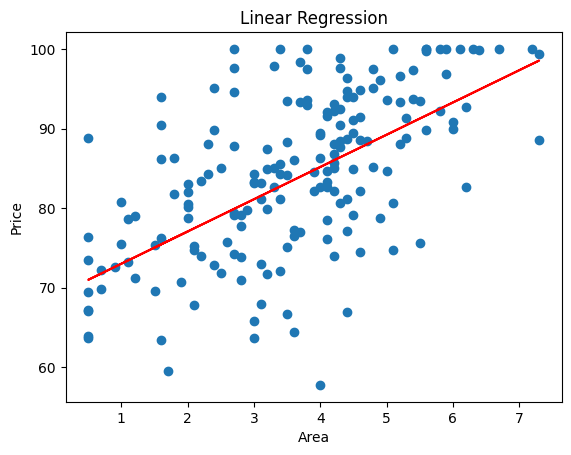

In [23]:
#Plotting the model output
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.show()

In [24]:
#Here WE Implemented the Linear Regression Algorithm From Scratch on the Dataset 
#This code is contributed byb Dev Kumar an aspiring AI Engineer
#If you liked my work then please upvote